In [1]:
%cd ..

/Users/omaistrenko/Library/CloudStorage/GoogleDrive-al.master2000@gmail.com/My Drive/Data Science/04 Deep Learning/reviews_classification


In [2]:
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score
from skorch import NeuralNetBinaryClassifier
from skorch.callbacks import Checkpoint, EarlyStopping, EpochScoring
from skorch.dataset import Dataset
from skorch.helper import predefined_split
from torch import nn
from torchinfo import summary

from src.neuralnet.model import TabBERT
from src.neuralnet.preprocess import prepare_data_skorch

In [3]:
TRANSFORMER_MODEL = "prajjwal1/bert-tiny"  # 'bert-base-uncased'
MAX_LENGTH = 512
SEED = 42

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(device)

mps


In [4]:
X_train, X_val, y_train, y_val, embedding_sizes, n_continuous = prepare_data_skorch(
    TRANSFORMER_MODEL, MAX_LENGTH
)

In [5]:
# Keep the checkpoint with the best validation ROC AUC
checkpoint = Checkpoint(
    monitor="valid_roc_auc_best",
    dirname="checkpoint/skorch",
    f_params="best_model.pt",
    f_optimizer=None,
    f_criterion=None,
    f_history=None,
)

net = NeuralNetBinaryClassifier(
    TabBERT,
    module__embedding_sizes=embedding_sizes,
    module__n_continuous=n_continuous,
    module__transformer_model=TRANSFORMER_MODEL,
    module__device_tm=device,
    criterion=nn.BCELoss,  # TabBERT already outputs sigmoid probabilities
    optimizer=torch.optim.Adam,
    lr=1e-5,  # Fine-tuning BERT with a small learning rate
    batch_size=1024,
    max_epochs=1,
    iterator_train__shuffle=True,
    train_split=predefined_split(Dataset(X_val, y_val)),  # Validate on the test split
    callbacks=[
        EpochScoring(
            "roc_auc", lower_is_better=False, on_train=True, name="train_roc_auc"
        ),
        EpochScoring("roc_auc", lower_is_better=False, name="valid_roc_auc"),
        EarlyStopping(monitor="valid_loss", patience=10),
        checkpoint,
    ],
    device=device,
)

In [6]:
# Set seeds for random modules
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

net.initialize()

input_example = {k: torch.as_tensor(v[:1], device=device) for k, v in X_train.items()}

pred_probab = net.module_(**input_example)
print("probabilities:", pred_probab)

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


probabilities: tensor([[0.5085]], device='mps:0', grad_fn=<SigmoidBackward0>)


In [7]:
summary(net.module_, input_data=input_example)

Layer (type:depth-idx)                                  Output Shape              Param #
TabBERT                                                 [1, 1]                    --
├─BertModel: 1-1                                        [1, 128]                  --
│    └─BertEmbeddings: 2-1                              [1, 512, 128]             --
│    │    └─Embedding: 3-1                              [1, 512, 128]             (3,906,816)
│    │    └─Embedding: 3-2                              [1, 512, 128]             (256)
│    │    └─Embedding: 3-3                              [1, 512, 128]             (65,536)
│    │    └─LayerNorm: 3-4                              [1, 512, 128]             (256)
│    │    └─Dropout: 3-5                                [1, 512, 128]             --
│    └─BertEncoder: 2-2                                 [1, 512, 128]             --
│    │    └─ModuleList: 3-6                             --                        (396,544)
│    └─BertPooler: 2-3          

In [8]:
# Set seeds for random modules
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# Train the model (partial_fit keeps the module initialized above, fit would re-create it)
net.partial_fit(X_train, y_train)

  epoch    train_loss    train_roc_auc    valid_acc    valid_loss    valid_roc_auc    cp       dur
-------  ------------  ---------------  -----------  ------------  ---------------  ----  --------
      1        0.6672           0.5192       0.7613        0.6597           0.5426     +  352.8214


,module,<class 'src.n...odel.TabBERT'>
,criterion,<class 'torch...loss.BCELoss'>
,train_split,functools.par... 0x17763ea50>)
,threshold,0.5
,optimizer,<class 'torch...im.adam.Adam'>
,lr,1e-05
,max_epochs,1
,batch_size,1024
,iterator_train,<class 'torch...r.DataLoader'>
,iterator_valid,<class 'torch...r.DataLoader'>
,dataset,<class 'skorc...aset.Dataset'>


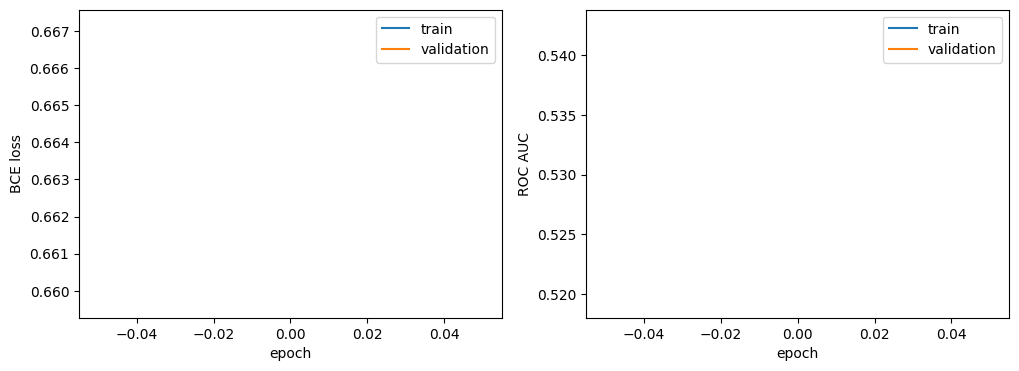

In [9]:
fig, (ax_loss, ax_auc) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(net.history[:, "train_loss"], label="train")
ax_loss.plot(net.history[:, "valid_loss"], label="validation")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("BCE loss")
ax_loss.legend()

ax_auc.plot(net.history[:, "train_roc_auc"], label="train")
ax_auc.plot(net.history[:, "valid_roc_auc"], label="validation")
ax_auc.set_xlabel("epoch")
ax_auc.set_ylabel("ROC AUC")
ax_auc.legend()

plt.show()

In [10]:
# Restore the best checkpoint
net.load_params(checkpoint=checkpoint)

# Predict probabilities
y_probs = net.predict_proba(X_val)[:, 1]

# Calculate ROC AUC Score
roc_auc = roc_auc_score(y_val, y_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.5426


In [ ]:
torch.save(net.module_.state_dict(), "data/model_skorch.pt")